## **Step 0: Import Libraries**

In [38]:
# Data Handling
import pandas as pd
import numpy as np
import json
import pprint


# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Supressing Unnecessary Warnings
import warnings

# File Handling
import os

# SimpleImputer


from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    f1_score,
)
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Supressing Warnings
warnings.simplefilter("ignore")
# Show all columns
pd.set_option("display.max_columns", None)


In [ ]:
# find the python environment this notebook is running in
import sys

print(sys.executable)


# Install xgboos in the full path c:\Users\fitsu\miniconda3\envs\venv\python.exe


c:\Users\fitsu\miniconda3\envs\venv\python.exe


In [3]:
# Get current working directory
cwd = os.getcwd()
print("Current working directory:", cwd)

# Change working directory to project root
os.chdir("../")
print("Changed working directory to root:", os.getcwd())


Current working directory: d:\MLops\PowerCo-Custumer-Churn\Notebooks
Changed working directory to root: d:\MLops\PowerCo-Custumer-Churn


## **Step 1: Load the Data**

In [5]:
prices_cut = pd.read_csv("Data/prices_cut.csv")
clients_ref = pd.read_csv("Data/clients_ref.csv")

print("Prices shape:", prices_cut.shape)
print("================" * 20)
print("Clients shape:", clients_ref.shape)

# Check for missing values in the datasets
print(
    "Missing values in prices_cut:\n",
    prices_cut.isnull().sum().sort_values(ascending=False),
)
print("================" * 20)
print(
    "Missing values in clients_ref:\n",
    clients_ref.isnull().sum().sort_values(ascending=False),
)


Prices shape: (90791, 9)
Clients shape: (14606, 29)
Missing values in prices_cut:
 id                    0
month                 0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
cutoff_month          0
dtype: int64
Missing values in clients_ref:
 id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_g

## **Step 2: Rolling/delta/volatility features per id (ending at cutoff), + time features from client dates**

### **Define the rolling feature function**
- We'll compute rolling mean, standard deviation, and month-over-month (MoM) differences for each column across windows.

In [6]:
price_cols = [
    "price_off_peak_var",
    "price_peak_var",
    "price_mid_peak_var",
    "price_off_peak_fix",
    "price_peak_fix",
    "price_mid_peak_fix",
]


def add_rolling_features(df: pd.DataFrame, cols, windows=(1, 3, 6, 12)):
    """
    For each id, compute rolling mean/std for given windows and simple month-over-month diff.
    Returns a DataFrame with original cols + engineered features.
    """
    out = df.sort_values(["id", "month"]).copy()  # Ensure sorted for rolling
    g = out.groupby("id", group_keys=False)

    # Rolling stats
    for w in windows:
        roll = g[cols].rolling(window=w, min_periods=1).agg(["mean", "std"])
        roll.columns = [f"{c}_roll{w}_{stat}" for c, stat in roll.columns]
        roll = roll.reset_index(level=0, drop=True)
        out = pd.concat([out, roll], axis=1)

    # Month-over-month deltas (first diff within id)
    mom = g[cols].diff().add_suffix("_mom")
    out = pd.concat([out, mom], axis=1)

    # Price-spread features (tariff shape proxy) for var and fix (current-month values)
    if set(["price_peak_var", "price_off_peak_var"]).issubset(out.columns):
        out["spread_var"] = out["price_peak_var"] - out["price_off_peak_var"]
    if set(["price_peak_fix", "price_off_peak_fix"]).issubset(out.columns):
        out["spread_fix"] = out["price_peak_fix"] - out["price_off_peak_fix"]

    return out


feat_long = add_rolling_features(prices_cut, price_cols, windows=(1, 3, 6, 12))

# Take the *latest available month per id* (which is exactly the cutoff month after filtering)
idx_last = feat_long.groupby("id")["month"].idxmax()
feat_at_cutoff = feat_long.loc[idx_last].drop(columns=["month"]).copy()

# Join back to client snapshot and create time-based features aligned to m_ref
X = clients_ref.merge(feat_at_cutoff, on="id", how="inner").copy()


In [43]:
print(X.shape)
print("================" * 20)
display(X.head(2))

(14217, 92)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,last_price_month,m_ref,cutoff_month_x,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,cutoff_month_y,price_off_peak_var_roll1_mean,price_off_peak_var_roll1_std,price_peak_var_roll1_mean,price_peak_var_roll1_std,price_mid_peak_var_roll1_mean,price_mid_peak_var_roll1_std,price_off_peak_fix_roll1_mean,price_off_peak_fix_roll1_std,price_peak_fix_roll1_mean,price_peak_fix_roll1_std,price_mid_peak_fix_roll1_mean,price_mid_peak_fix_roll1_std,price_off_peak_var_roll3_mean,price_off_peak_var_roll3_std,price_peak_var_roll3_mean,price_peak_var_roll3_std,price_mid_peak_var_roll3_mean,price_mid_peak_var_roll3_std,price_off_peak_fix_roll3_mean,price_off_peak_fix_roll3_std,price_peak_fix_roll3_mean,price_peak_fix_roll3_std,price_mid_peak_fix_roll3_mean,price_mid_peak_fix_roll3_std,price_off_peak_var_roll6_mean,price_off_peak_var_roll6_std,price_peak_var_roll6_mean,price_peak_var_roll6_std,price_mid_peak_var_roll6_mean,price_mid_peak_var_roll6_std,price_off_peak_fix_roll6_mean,price_off_peak_fix_roll6_std,price_peak_fix_roll6_mean,price_peak_fix_roll6_std,price_mid_peak_fix_roll6_mean,price_mid_peak_fix_roll6_std,price_off_peak_var_roll12_mean,price_off_peak_var_roll12_std,price_peak_var_roll12_mean,price_peak_var_roll12_std,price_mid_peak_var_roll12_mean,price_mid_peak_var_roll12_std,price_off_peak_fix_roll12_mean,price_off_peak_fix_roll12_std,price_peak_fix_roll12_mean,price_peak_fix_roll12_std,price_mid_peak_fix_roll12_mean,price_mid_peak_fix_roll12_std,price_off_peak_var_mom,price_peak_var_mom,price_mid_peak_var_mom,price_off_peak_fix_mom,price_peak_fix_mom,price_mid_peak_fix_mom,spread_var,spread_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-12-31,2015-06-23,2015-05-31,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383,2015-05-31,0.125976,NaN,0.103395,NaN,0.071536,NaN,40.565973,NaN,24.339578,NaN,16.226383,NaN,0.125976,0.0,0.103395,0.0,0.071536,0.0,40.565973,0.0,24.339578,0.0,16.226383,0.0,0.125976,0.0,0.103395,0.0,0.071536,0.0,40.565972,1.971801e-06,24.339579,0.000001,16.226385,0.000003,0.125976,0.0,0.103395,0.0,0.071536,0.0,40.565972,1.971801e-06,24.339579,0.000001,16.226385,0.000003,0.0,0.0,0.0,0.0,0.0,0.0,-0.022581,-16.226395
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,2015-12-31,2015-08-31,2015-07-31,0.151367,0.000000,0.000000,44.266930,0.000000,0.000000,2015-07-31,0.151367,NaN,0.000000,NaN,0.000000,NaN,44.266930,NaN,0.000000,NaN,0.000000,NaN,0.151367,0.0,0.000000,0.0,0.000000,0.0,44.266930,0.0,0.000000,0.0,0.000000,0.0,0.151367,0.0,0.000000,0.0,0.000000,0.0,44.266930,6.196773e-07,0.000000,0.000000,0.000000,0.000000,0.151367,0.0,0.000000,0.0,0.000000,0.0,44.266930,6.414270e-07,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-0.151367,-44.266930


### **Quick missingness report on X (before imputation)**
- NaNs are expected after creating rolling features, as customers with short price histories (e.g., <12 months) will have missing values for longer rolling windows (e.g., roll12_mean). The code identifies and handles them systematically to prepare a clean feature matrix for modeling.


In [7]:
# 1) Quick missingness report on X (before imputation)
null_report = (
    X.isna().mean().sort_values(ascending=False).rename("missing_rate").to_frame()
)
display(null_report.head(30))  # inspect top missing features


,missing_rate
price_off_peak_var_roll1_std,1.000000
price_peak_var_roll1_std,1.000000
price_off_peak_fix_roll1_std,1.000000
price_mid_peak_var_roll1_std,1.000000
price_peak_fix_roll1_std,1.000000
price_mid_peak_fix_roll1_std,1.000000
price_off_peak_var_mom,0.093902
price_peak_var_mom,0.093902
price_off_peak_var_roll12_std,0.093902
price_peak_var_roll12_std,0.093902


In [ ]:
# Filter the report to only include columns that actually have missing data
missing_cols_report = null_report[null_report["missing_rate"] > 0]

# Initialize an empty dictionary to hold the families
families = {}

# Iterate over the column names that have missing values
for col_name in missing_cols_report.index:
    # We assume the pattern is always 'base_name' + '_roll' + details
    if "_roll" in col_name:
        # Extract the base name by splitting the string at "_roll"
        base_name = col_name.split("_roll")[0]

        # If this is the first time we see this base name,
        # create a new list for it in the dictionary.
        if base_name not in families:
            families[base_name] = []

        # Add the full column name to its family.
        families[base_name].append(col_name)

# Optional: Sort the lists within the dictionary to match the original order.
# A reverse sort works here because 'roll6' comes before 'roll12' alphabetically.
for key in families:
    families[key].sort(reverse=True)




print(json.dumps(families, indent=4))


{
    "price_off_peak_var": [
        "price_off_peak_var_roll6_std",
        "price_off_peak_var_roll3_std",
        "price_off_peak_var_roll1_std",
        "price_off_peak_var_roll12_std"
    ],
    "price_peak_var": [
        "price_peak_var_roll6_std",
        "price_peak_var_roll3_std",
        "price_peak_var_roll1_std",
        "price_peak_var_roll12_std"
    ],
    "price_off_peak_fix": [
        "price_off_peak_fix_roll6_std",
        "price_off_peak_fix_roll3_std",
        "price_off_peak_fix_roll1_std",
        "price_off_peak_fix_roll12_std"
    ],
    "price_mid_peak_var": [
        "price_mid_peak_var_roll6_std",
        "price_mid_peak_var_roll3_std",
        "price_mid_peak_var_roll1_std",
        "price_mid_peak_var_roll12_std"
    ],
    "price_peak_fix": [
        "price_peak_fix_roll6_std",
        "price_peak_fix_roll3_std",
        "price_peak_fix_roll1_std",
        "price_peak_fix_roll12_std"
    ],
    "price_mid_peak_fix": [
        "price_mid_peak_fix_roll6_s

### **2) Identify rolling feature families to apply hierarchical fallback**

In [10]:
families = {
    # variable pricing family
    "price_peak_var": [
        "price_peak_var_roll12_mean",
        "price_peak_var_roll6_mean",
        "price_peak_var_roll3_mean",
        "price_peak_var_roll1_mean",
    ],
    "price_mid_peak_var": [
        "price_mid_peak_var_roll12_mean",
        "price_mid_peak_var_roll6_mean",
        "price_mid_peak_var_roll3_mean",
        "price_mid_peak_var_roll1_mean",
    ],
    "price_off_peak_var": [
        "price_off_peak_var_roll12_mean",
        "price_off_peak_var_roll6_mean",
        "price_off_peak_var_roll3_mean",
        "price_off_peak_var_roll1_mean",
    ],
    # fixed pricing family
    "price_peak_fix": [
        "price_peak_fix_roll12_mean",
        "price_peak_fix_roll6_mean",
        "price_peak_fix_roll3_mean",
        "price_peak_fix_roll1_mean",
    ],
    "price_mid_peak_fix": [
        "price_mid_peak_fix_roll12_mean",
        "price_mid_peak_fix_roll6_mean",
        "price_mid_peak_fix_roll3_mean",
        "price_mid_peak_fix_roll1_mean",
    ],
    "price_off_peak_fix": [
        "price_off_peak_fix_roll12_mean",
        "price_off_peak_fix_roll6_mean",
        "price_off_peak_fix_roll3_mean",
        "price_off_peak_fix_roll1_mean",
    ],
}

X_imp = X.copy()


In [ ]:
print(X_imp.shape)
print("================" * 20)
display(X_imp.head(2))


(14217, 101)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,last_price_month,m_ref,cutoff_month_x,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,cutoff_month_y,price_off_peak_var_roll1_mean,price_peak_var_roll1_mean,price_mid_peak_var_roll1_mean,price_off_peak_fix_roll1_mean,price_peak_fix_roll1_mean,price_mid_peak_fix_roll1_mean,price_off_peak_var_roll3_mean,price_off_peak_var_roll3_std,price_peak_var_roll3_mean,price_peak_var_roll3_std,price_mid_peak_var_roll3_mean,price_mid_peak_var_roll3_std,price_off_peak_fix_roll3_mean,price_off_peak_fix_roll3_std,price_peak_fix_roll3_mean,price_peak_fix_roll3_std,price_mid_peak_fix_roll3_mean,price_mid_peak_fix_roll3_std,price_off_peak_var_roll6_mean,price_off_peak_var_roll6_std,price_peak_var_roll6_mean,price_peak_var_roll6_std,price_mid_peak_var_roll6_mean,price_mid_peak_var_roll6_std,price_off_peak_fix_roll6_mean,price_off_peak_fix_roll6_std,price_peak_fix_roll6_mean,price_peak_fix_roll6_std,price_mid_peak_fix_roll6_mean,price_mid_peak_fix_roll6_std,price_off_peak_var_roll12_mean,price_off_peak_var_roll12_std,price_peak_var_roll12_mean,price_peak_var_roll12_std,price_mid_peak_var_roll12_mean,price_mid_peak_var_roll12_std,price_off_peak_fix_roll12_mean,price_off_peak_fix_roll12_std,price_peak_fix_roll12_mean,price_peak_fix_roll12_std,price_mid_peak_fix_roll12_mean,price_mid_peak_fix_roll12_std,price_off_peak_var_mom,price_peak_var_mom,price_mid_peak_var_mom,price_off_peak_fix_mom,price_peak_fix_mom,price_mid_peak_fix_mom,spread_var,spread_fix,price_peak_var_roll_best_mean,price_peak_var_roll_best_mean_na,price_mid_peak_var_roll_best_mean,price_mid_peak_var_roll_best_mean_na,price_off_peak_var_roll_best_mean,price_off_peak_var_roll_best_mean_na,price_peak_fix_roll_best_mean,price_peak_fix_roll_best_mean_na,price_mid_peak_fix_roll_best_mean,price_mid_peak_fix_roll_best_mean_na,price_off_peak_fix_roll_best_mean,price_off_peak_fix_roll_best_mean_na,spread_var_best,spread_fix_best,short_history_flag
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-12-31,2015-06-23,2015-05-31,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383,2015-05-31,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383,0.125976,0.0,0.103395,0.0,0.071536,0.0,40.565973,0.0,24.339578,0.0,16.226383,0.0,0.125976,0.0,0.103395,0.0,0.071536,0.0,40.565972,1.971801e-06,24.339579,0.000001,16.226385,0.000003,0.125976,0.0,0.103395,0.0,0.071536,0.0,40.565972,1.971801e-06,24.339579,0.000001,16.226385,0.000003,0.0,0.0,0.0,0.0,0.0,0.0,-0.022581,-16.226395,0.103395,0,0.071536,0,0.125976,0,24.339579,0,16.226385,0,40.565972,0,-0.022581,-16.226392,0
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,2015-12-31,2015-08-31,2015-07-31,0.151367,0.000000,0.000000,44.266930,0.000000,0.000000,2015-07-31,0.151367,0.000000,0.000000,44.266930,0.000000,0.000000,0.151367,0.0,0.000000,0.0,0.000000,0.0,44.266930,0.0,0.000000,0.0,0.000000,0.0,0.151367,0.0,0.000000,0.0,0.000000,0.0,44.266930,6.196773e-07,0.000000,0.000000,0.000000,0.000000,0.151367,0.0,0.000000,0.0,0.000000,0.0,44.266930,6.414270e-07,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-0.151367,-44.266930,0.000000,0,0.000000,0,0.151367,0,0.000000,0,0.000000,0,44.266930,0,-0.151367,-44.266930,0


In [12]:
# 1) Replace inf/-inf with NaN so the imputer can handle them
num_mask = X_imp.select_dtypes(include=[np.number]).columns
X_imp[num_mask] = X_imp[num_mask].replace([np.inf, -np.inf], np.nan)

# 2) Identify and DROP columns that are entirely NaN (these cause shape drops in SimpleImputer)
num_cols_allnan = [c for c in num_mask if X_imp[c].isna().all()]

# 3) Identify ZERO-VARIANCE columns and drop them (no signal)
# Removes columns with no variation (constant values), as they add no predictive value.
num_cols_zerovar = []
for c in num_mask:
    s = X_imp[c].dropna()
    if s.empty:
        continue
    if s.nunique(dropna=True) == 1:
        num_cols_zerovar.append(c)

# It identifies columns that are useless for machine learning (because they are either empty or constant) and collects their names into a single, de-duplicated list called cols_to_drop
cols_to_drop = sorted(set(num_cols_allnan + num_cols_zerovar))
X_imp = X_imp.drop(columns=cols_to_drop)

pprint.pprint(
    {
        "dropped_all_nan": num_cols_allnan,
        "dropped_zero_variance": num_cols_zerovar,
        "remaining_numeric_cols": len(X_imp.select_dtypes(include=[np.number]).columns),
    }
)


{'dropped_all_nan': ['price_off_peak_var_roll1_std',
                     'price_peak_var_roll1_std',
                     'price_mid_peak_var_roll1_std',
                     'price_off_peak_fix_roll1_std',
                     'price_peak_fix_roll1_std',
                     'price_mid_peak_fix_roll1_std'],
 'dropped_zero_variance': [],
 'remaining_numeric_cols': 74}


### **Handling: Hierarchical Fallback for Rolling Features**
- A helper function, hierarchical_fill, was defined to implement a reusable, prioritized filling strategy. The function is designed to operate on a single row of data and takes an ordered list of column names as input, which represents the hierarchy. It iterates through this list and returns the value from the first column that contains a non-missing entry. If all columns in the priority list are null for that particular row, the function returns a null value. This function serves as the core engine for consolidating information from multiple, related columns into a single, more complete value

In [15]:
def hierarchical_fill(row, cols):
    for c in cols:
        v = row.get(c, np.nan)
        if pd.notna(v):
            return v
    return np.nan


-  We consolidated multiple rolling-average features into a single, more robust feature for each pricing family. Using a hierarchical filling approach, we created a new ..._roll_best_mean column by searching through a prioritized list of rolling averages (e.g., from 12-month down to 1-month) and selecting the first available non-missing value for each customer. This ensures the new feature represents the most stable historical data available. Alongside this, we generated a corresponding ..._na binary flag to explicitly indicate rows where no data could be found, preserving the original missingness information as a potentially predictive signal.

In [16]:
# 3) Create compact “best available” roll-mean for each family and flag missingness
for base, cols in families.items():
    cols_present = [c for c in cols if c in X_imp.columns]
    if not cols_present:
        continue
    out_col = f"{base}_roll_best_mean"
    na_flag = f"{out_col}_na"
    X_imp[out_col] = X_imp[cols_present].apply(
        lambda r: hierarchical_fill(r, cols_present), axis=1
    )
    X_imp[na_flag] = X_imp[out_col].isna().astype(int)
    print(f"Created {out_col} with {X_imp[out_col].isna().mean():.2%} missing")

Created price_peak_var_roll_best_mean with 0.00% missing
Created price_mid_peak_var_roll_best_mean with 0.00% missing
Created price_off_peak_var_roll_best_mean with 0.00% missing
Created price_peak_fix_roll_best_mean with 0.00% missing
Created price_mid_peak_fix_roll_best_mean with 0.00% missing
Created price_off_peak_fix_roll_best_mean with 0.00% missing


- To further enhance our feature set, we engineered two new columns to represent the price spread, which is the difference between peak and off-peak prices. Rather than relying on potentially volatile or missing single-month data, we calculated these spreads using the robust ...roll_best_mean columns previously created. This method provides a more stable and reliable measure of the typical price spread a customer is exposed to. The resulting features, spread_var_best and spread_fix_best, capture this information for both the variable and fixed pricing structures, respectively, making them less sensitive to short-term anomalies.

In [18]:
# 4) Recompute spreads at cutoff using the “best” means (more robust than single-month values)
def try_spread(a, b):
    return (a - b) if (pd.notna(a) and pd.notna(b)) else np.nan


X_imp["spread_var_best"] = [
    try_spread(p, o)
    for p, o in zip(
        X_imp.get("price_peak_var_roll_best_mean"),
        X_imp.get("price_off_peak_var_roll_best_mean"),
    )
]
X_imp["spread_fix_best"] = [
    try_spread(p, o)
    for p, o in zip(
        X_imp.get("price_peak_fix_roll_best_mean"),
        X_imp.get("price_off_peak_fix_roll_best_mean"),
    )
]
print(
    f"Created spread_var_best with {X_imp['spread_var_best'].isna().mean():.2%} missing"
)
print(
    f"Created spread_fix_best with {X_imp['spread_fix_best'].isna().mean():.2%} missing"
)

Created spread_var_best with 0.00% missing
Created spread_fix_best with 0.00% missing


- The main purpose of this code is to create a single binary flag (1 or 0), short_history_flag, to identify customers who likely have a short history with the company. A customer's tenure is often a strong predictor in churn models, and this is a smart way to create a feature that captures that information.

In [19]:
# 5) Light “short history” flag (helps models)
# If many original roll12 features are NaN, the customer likely has short history.
roll12_cols = [c for c in X_imp.columns if "roll12_" in c]
X_imp["short_history_flag"] = X_imp[roll12_cols].isna().mean(axis=1).gt(0.5).astype(int)

print(
    "Added roll_best*, spread_*_best, and missing flags. Next: median-impute remaining NaNs."
)


Added roll_best*, spread_*_best, and missing flags. Next: median-impute remaining NaNs.


- The purpose of this code is to select the exact set of columns that will be fed into the machine learning model. This involves two main actions:

    - Excluding columns that should never be features.
    - Separating the remaining features by data type (numeric vs. categorical) for preprocessing.

In [20]:
# 1) Build the feature matrix to model with:
#    - Keep previously engineered, leak-safe features
#    - Prefer the new *_roll_best_mean and *_spread_best where available
label_col = "churn"

# Columns never used as features
exclude_cols = {
    "id",
    "m_ref",
    "cutoff_month",
    "last_price_month",
    "date_activ",
    "date_end",
    "date_modif_prod",
    "date_renewal",
    label_col,
}

# Prefer best versions if present; keep other engineered features too
candidate_cols = [c for c in X_imp.columns if c not in exclude_cols]

# Separate numeric vs (potential) categoricals
num_cols = X_imp[candidate_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in candidate_cols if c not in num_cols]


- The purpose of this code is to handle any and all remaining missing values (NaNs) in the feature set and to assemble the final, clean X_model (features) and y_model (labels) that will be fed into the model. The previous steps were smart and reduced many NaNs, but this step ensures absolutely none are left.

In [31]:
# 2) Impute
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent") if cat_cols else None

# Fit/transform numeric
num_arr = num_imputer.fit_transform(X_imp[num_cols])
X_num = pd.DataFrame(num_arr, columns=num_cols, index=X_imp.index)

# Fit/transform categoricals (if any)
if cat_cols:
    cat_arr = cat_imputer.fit_transform(X_imp[cat_cols])
    X_cat = pd.DataFrame(cat_arr, columns=cat_cols, index=X_imp.index)
    X_clean = pd.concat([X_num, X_cat], axis=1)
else:
    X_clean = X_num

# 3) One-hot encode categoricals to numerical (required for SMOTE and sklearn trees)
X_encoded = pd.get_dummies(
    X_clean, columns=cat_cols, drop_first=True
)  # drop_first to avoid multicollinearity if needed, but trees handle it

# Restore m_ref for chronological splits; y for labels
X_model = X_imp[["m_ref"]].join(X_encoded)
y_model = X_imp[label_col].astype(int)

print(
    {
        "X_model_shape": X_model.shape,
        "n_features": X_encoded.shape[1],
        "remaining_null_rate": float(pd.isna(X_encoded).mean().mean()),
        "all_numerical": X_encoded.select_dtypes(include=[np.number]).shape[1]
        == X_encoded.shape[1],
    }
)

# Map 'has_gas' to numeric values (assuming 't' = 1, 'f' = 0) - note: if 'has_gas' is categorical, it will be encoded above
# If 'has_gas' is already in cat_cols, skip this; otherwise, adjust
if "has_gas" in X_model.columns and X_model["has_gas"].dtype == object:
    X_model["has_gas"] = X_model["has_gas"].map({"t": 1, "f": 0})

# Create artifacts directory if it doesn't exist
os.makedirs("artifacts", exist_ok=True)

# persist the leak-safe matrix for reproducibility
X_model.to_csv("artifacts/X_model.csv", index=False)
y_model.to_frame("y").to_csv("artifacts/y_model.csv", index=False)

# ---- Chronological Split by m_ref (60/20/20) ----
# Purpose: Split data temporally to prevent data leakage.
X_model["m_ref"] = pd.to_datetime(X_model["m_ref"], errors="coerce")

q_train_end = X_model["m_ref"].quantile(0.60)
q_val_end = X_model["m_ref"].quantile(0.80)

train_ix = X_model["m_ref"] <= q_train_end
val_ix = (X_model["m_ref"] > q_train_end) & (X_model["m_ref"] <= q_val_end)
test_ix = X_model["m_ref"] > q_val_end

feature_cols = [c for c in X_model.columns if c != "m_ref"]
X_tr, y_tr = X_model.loc[train_ix, feature_cols], y_model.loc[train_ix]
X_va, y_va = X_model.loc[val_ix, feature_cols], y_model.loc[val_ix]
X_te, y_te = X_model.loc[test_ix, feature_cols], y_model.loc[test_ix]
print({"train": X_tr.shape, "val": X_va.shape, "test": X_te.shape})


{'X_model_shape': (14217, 122), 'n_features': 121, 'remaining_null_rate': 0.0, 'all_numerical': False}
{'train': (8534, 121), 'val': (2892, 121), 'test': (2791, 121)}


## **Modeling**

- Chronological Split by m_ref (60/20/20)

In [34]:
# Purpose: Split data temporally to prevent data leakage.
X_model["m_ref"] = pd.to_datetime(X_model["m_ref"], errors="coerce")

q_train_end = X_model["m_ref"].quantile(0.60)
q_val_end = X_model["m_ref"].quantile(0.80)

train_ix = X_model["m_ref"] <= q_train_end
val_ix = (X_model["m_ref"] > q_train_end) & (X_model["m_ref"] <= q_val_end)
test_ix = X_model["m_ref"] > q_val_end

feature_cols = [c for c in X_model.columns if c != "m_ref"]
X_tr, y_tr = X_model.loc[train_ix, feature_cols], y_model.loc[train_ix]
X_va, y_va = X_model.loc[val_ix, feature_cols], y_model.loc[val_ix]
X_te, y_te = X_model.loc[test_ix, feature_cols], y_model.loc[test_ix]
print({"train": X_tr.shape, "val": X_va.shape, "test": X_te.shape})


{'train': (8534, 121), 'val': (2892, 121), 'test': (2791, 121)}


- Models: Random Forest and XGBoost with SMOTE

In [36]:
smote = SMOTE(random_state=42, k_neighbors=5)

# Random Forest + SMOTE
rf_smote = ImbPipeline(
    steps=[
        ("smote", smote),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
).fit(X_tr, y_tr)
rf_cal = CalibratedClassifierCV(rf_smote, cv="prefit", method="isotonic").fit(
    X_va, y_va
)

# XGBoost + SMOTE
xgb_smote = ImbPipeline(
    steps=[
        ("smote", smote),
        (
            "clf",
            xgb.XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
).fit(X_tr, y_tr)
xgb_cal = CalibratedClassifierCV(xgb_smote, cv="prefit", method="isotonic").fit(
    X_va, y_va
)


- Evaluation


[RF+SMOTE-Cal]   {'pr_auc': 0.11783102039957805, 'roc_auc': 0.587696788252785, 'brier': 0.08823840095242556, 'best_f1_macro': 0.5119539641047381, 'thr_f1_macro': np.float64(0.18), 'best_expected_utility': np.float64(200.0), 'thr_expected_utility': np.float64(0.06), 'recall@top_k_pct': np.float64(0.13186813186813187), 'k': 280}
[XGB+SMOTE-Cal] {'pr_auc': 0.13639529025560482, 'roc_auc': 0.6160421521819458, 'brier': 0.08738297581560683, 'best_f1_macro': 0.5308189500179792, 'thr_f1_macro': np.float64(0.16999999999999998), 'best_expected_utility': np.float64(1000.0), 'thr_expected_utility': np.float64(0.05), 'recall@top_k_pct': np.float64(0.17216117216117216), 'k': 280}

>>> Winner by PR-AUC: XGB+SMOTE-Cal


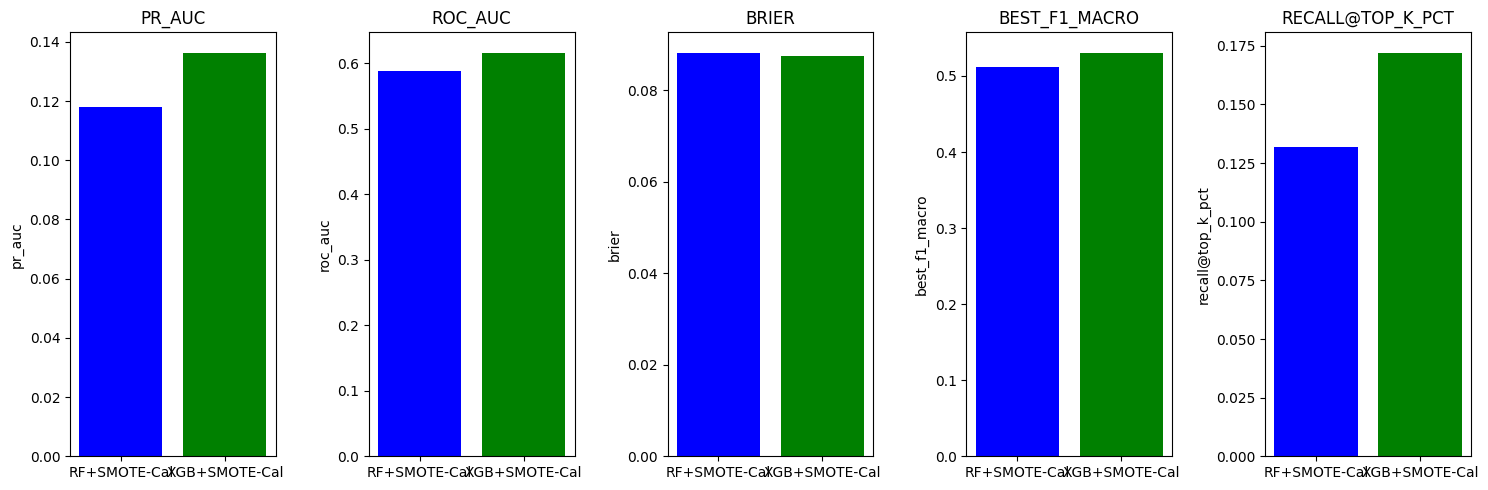


Performance Summary:
           Model    pr_auc   roc_auc     brier  best_f1_macro  \
0   RF+SMOTE-Cal  0.117831  0.587697  0.088238       0.511954   
1  XGB+SMOTE-Cal  0.136395  0.616042  0.087383       0.530819   

   recall@top_k_pct  
0          0.131868  
1          0.172161  


In [37]:
def eval_with_utility(model, X, y, offer_cost=50.0, churn_loss=500.0, top_k_pct=0.10):
    p = model.predict_proba(X)[:, 1]
    pr_auc = average_precision_score(y, p)
    roc = roc_auc_score(y, p)
    brier = brier_score_loss(y, p)

    thresholds = np.linspace(0.05, 0.95, 91)
    best_f1, thr_f1 = -1, 0.5
    best_util, thr_util = -1e18, 0.5
    for t in thresholds:
        pred = (p >= t).astype(int)
        f1m = f1_score(y, pred, average="macro")
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        util = (tp * churn_loss) - ((tp + fp) * offer_cost) - (fn * churn_loss)
        if f1m > best_f1:
            best_f1, thr_f1 = f1m, t
        if util > best_util:
            best_util, thr_util = util, t

    k = max(1, int(np.ceil(len(p) * top_k_pct)))
    top_idx = np.argsort(-p)[:k]
    recall_at_k = np.sum(y.iloc[top_idx] == 1) / max(1, np.sum(y == 1))

    return {
        "pr_auc": pr_auc,
        "roc_auc": roc,
        "brier": brier,
        "best_f1_macro": best_f1,
        "thr_f1_macro": thr_f1,
        "best_expected_utility": best_util,
        "thr_expected_utility": thr_util,
        "recall@top_k_pct": recall_at_k,
        "k": k,
    }


# Evaluate on test set
rf_metrics = eval_with_utility(rf_cal, X_te, y_te)
xgb_metrics = eval_with_utility(xgb_cal, X_te, y_te)

print("\n[RF+SMOTE-Cal]  ", rf_metrics)
print("[XGB+SMOTE-Cal]", xgb_metrics)

# Determine winner by PR-AUC
winner = (
    ("RF+SMOTE-Cal", rf_metrics)
    if rf_metrics["pr_auc"] >= xgb_metrics["pr_auc"]
    else ("XGB+SMOTE-Cal", xgb_metrics)
)
print(f"\n>>> Winner by PR-AUC: {winner[0]}")

# ---- Visualizations for Performance Comparison ----


models = ["RF+SMOTE-Cal", "XGB+SMOTE-Cal"]
metrics = ["pr_auc", "roc_auc", "brier", "best_f1_macro", "recall@top_k_pct"]
rf_vals = [rf_metrics[m] for m in metrics]
xgb_vals = [xgb_metrics[m] for m in metrics]

fig, axes = plt.subplots(1, len(metrics), figsize=(15, 5))
for i, m in enumerate(metrics):
    axes[i].bar(models, [rf_vals[i], xgb_vals[i]], color=["blue", "green"])
    axes[i].set_title(f"{m.upper()}")
    axes[i].set_ylabel(m)
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame(
    {"Model": models, **{m: [rf_vals[i], xgb_vals[i]] for i, m in enumerate(metrics)}}
)
print("\nPerformance Summary:")
print(summary_df)


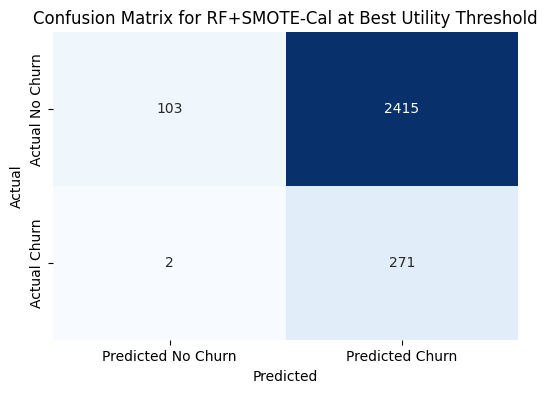

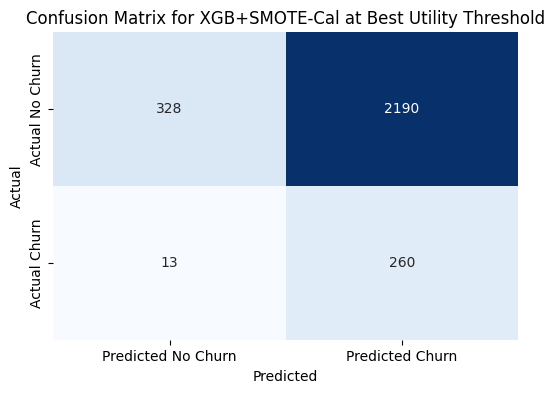

In [41]:
# Function to plot confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted No Churn", "Predicted Churn"],
        yticklabels=["Actual No Churn", "Actual Churn"],
    )
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()


# Plot for RF
plot_confusion_matrix(
    rf_metrics["confusion_matrix"],
    "Confusion Matrix for RF+SMOTE-Cal at Best Utility Threshold",
)

# Plot for XGB
plot_confusion_matrix(
    xgb_metrics["confusion_matrix"],
    "Confusion Matrix for XGB+SMOTE-Cal at Best Utility Threshold",
)
